# Quantum Algorithms with Qiskit — Oracles, Deutsch–Jozsa & Grover's Search

**Quantum Computing Spring School 2026**
Session 4 · Qiskit Lab II: Basics of Quantum Computing

In [Session 3](../session-3-quantum-computing-qiskit/03_intro_quantum_computing_qiskit.ipynb) we built the vocabulary of quantum computing — states, unitaries, circuits, measurement — first by hand in NumPy/SciPy, then in Qiskit with `QuantumCircuit`, `Statevector`, `SparsePauliOp`, `Sampler`, and `Estimator`. Today we use that vocabulary to build our first genuine **quantum algorithms**: circuits that solve a problem provably faster than any classical algorithm can.

We'll cover two algorithms that share a common trick — encoding the answer to a problem in the *phase* of a quantum state rather than in its amplitude directly:

1. **Deutsch–Jozsa**, a toy problem that is the cleanest possible illustration of a quantum speedup: one quantum query where the best classical algorithm needs exponentially many.
2. **Grover's algorithm**, the famous **quadratic speedup** for unstructured search — turning an $O(N)$ classical search into an $O(\sqrt{N})$ quantum one.

**Scope note, as before:** everything today runs on classical simulators — `Statevector`, `StatevectorSampler`, and `qiskit-aer`'s `AerSimulator`. No real hardware. The circuits here are small (a handful of qubits), so simulation is fast and exact amplitudes are always available to inspect, which is exactly what we want for building intuition.

**What we'll cover today:**

1. Setup and a quick recap
2. Oracles and phase kickback — the trick both algorithms rely on
3. The Deutsch–Jozsa algorithm
4. Grover's algorithm: searching an unstructured space
5. How many iterations? Visualising Grover's oscillation
6. Wrap-up

Each section has one or more **Exercises** — attempt them before running the solution cell underneath.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=4, suppress=True)

---

## 1. Setup and a quick recap

A one-cell refresher of the four Qiskit objects we'll lean on most today, carried straight over from Session 3:

- `QuantumCircuit` — build a circuit by appending gates to qubits.
- `Statevector(qc)` — the *exact* statevector produced by a (measurement-free) circuit, useful for inspecting what's going on without any shot noise.
- `StatevectorSampler` — run a circuit with `measure_all()` (or explicit `measure` calls) for some number of `shots` and get back counts.
- Qiskit's **little-endian** bit-ordering convention: qubit 0 is the *rightmost* character in a returned bitstring. This bit us in Session 3 and it will matter again today, so we'll call it out explicitly wherever it's relevant.

In [2]:
# sanity check: everything still imports and runs
qc_demo = QuantumCircuit(2)
qc_demo.h(0)
qc_demo.cx(0, 1)
print(Statevector(qc_demo))

Statevector([0.7071+0.j, 0.    +0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2))


---

## 2. Oracles and phase kickback

Every algorithm today is built around an **oracle**: a black-box unitary $U_f$ that "knows" a function $f$ we're trying to learn something about, without us ever getting to see $f$'s source code — only what querying $U_f$ tells us.

### 2.1 Bit oracles vs. phase oracles

The most natural way to make a function $f:\{0,1\}^n \to \{0,1\}$ reversible (required for any quantum circuit) is a **bit oracle**:

$$
U_f : |x\rangle|y\rangle \;\longmapsto\; |x\rangle|y \oplus f(x)\rangle .
$$

It writes $f(x)$ into an extra "answer" qubit rather than overwriting the input — that's what makes it reversible even when $f$ itself isn't injective.

Both algorithms today actually want a **phase oracle** instead: a unitary that leaves every basis state where it lives, but multiplies the ones satisfying some condition by $-1$:

$$
U_f^{\text{phase}} : |x\rangle \;\longmapsto\; (-1)^{f(x)} |x\rangle .
$$

The two are the same oracle in disguise. The bridge between them is a neat one-line trick called **phase kickback**.

### 2.2 Phase kickback, worked by hand

Take a bit oracle $U_f$ and prepare its answer qubit in the state $|-\rangle = \frac{1}{\sqrt2}(|0\rangle - |1\rangle)$ instead of $|0\rangle$ or $|1\rangle$. Watch what happens to a single input basis state $|x\rangle$:

$$
U_f : |x\rangle|-\rangle = |x\rangle \tfrac{1}{\sqrt2}\big(|0\rangle - |1\rangle\big)
\;\longmapsto\;
\tfrac{1}{\sqrt2}\big(|x\rangle|0 \oplus f(x)\rangle - |x\rangle|1 \oplus f(x)\rangle\big)
= (-1)^{f(x)}\,|x\rangle|-\rangle .
$$

If $f(x)=0$ nothing changes; if $f(x)=1$ the two terms inside $|-\rangle$ swap, which is exactly $-|-\rangle$. Either way, the answer qubit is left completely untouched (still $|-\rangle$) and the phase $(-1)^{f(x)}$ has been "kicked back" onto the *input* register. That's the whole trick: an oracle built to write bits into an ancilla ends up, with the right ancilla state, acting as a phase oracle on the input alone.

Let's check this numerically for the simplest nontrivial case, $f(x) = x$ (a CNOT oracle, one input qubit):

In [3]:
qc_kickback = QuantumCircuit(2)
qc_kickback.h(0)                 # input qubit in |+>: equal superposition of x=0, x=1
qc_kickback.x(1)
qc_kickback.h(1)                 # ancilla qubit in |->
qc_kickback.cx(0, 1)             # bit oracle for f(x) = x

sv = Statevector(qc_kickback)
print(sv)

Statevector([ 0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j],
            dims=(2, 2))


**Exercise:** predict, before running, what the output amplitudes should look like. We started with $|+\rangle|-\rangle = \frac12(|0\rangle - |1\rangle + |2\rangle - |3\rangle)$ in the computational basis (using the 2-qubit index, little-endian: `|q1 q0>`). Phase kickback with $f(x)=x$ should flip the sign of exactly the $x=1$ terms relative to that, i.e. the amplitude of `'10'` (qubit 0 = 1, ancilla = 1) should have an *extra* sign flip on top of the $-1$ already present from $|-\rangle$'s own $|1\rangle$ component. Confirm by comparing to `Statevector` of the circuit *without* the CNOT.

In [4]:
qc_no_oracle = QuantumCircuit(2)
qc_no_oracle.h(0)
qc_no_oracle.x(1)
qc_no_oracle.h(1)

sv_no_oracle = Statevector(qc_no_oracle)
print("without oracle:", sv_no_oracle)
print("with oracle:   ", sv)
print("ratio (should be ±1 for each nonzero amplitude):")
ratio = np.divide(sv.data, sv_no_oracle.data, out=np.zeros_like(sv.data), where=np.abs(sv_no_oracle.data) > 1e-9)
print(np.round(ratio.real))

without oracle: Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
            dims=(2, 2))
with oracle:    Statevector([ 0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j],
            dims=(2, 2))
ratio (should be ±1 for each nonzero amplitude):
[ 1. -1.  1. -1.]


You should see the ancilla ($|-\rangle$) is unaffected — it's still a $\pm1$ ratio across the board — but the sign attached to the $x=1$ branch has flipped relative to $x=0$. That flipped relative sign on the *input register alone* is the phase oracle $(-1)^{f(x)}$ we wanted, and it's now something a Hadamard-based algorithm can turn into an observable difference in probabilities. Deutsch–Jozsa and Grover both work by engineering the input register into exactly this kind of relative-phase pattern and then using interference (via `H` gates, or via the full "diffusion" step in Grover) to make it show up in measurement outcomes.

---

## 3. The Deutsch–Jozsa algorithm

### 3.1 The problem

You're given (oracle access to) a function $f : \{0,1\}^n \to \{0,1\}$ with a **promise**: $f$ is either

- **constant** — the same value for every input, or
- **balanced** — exactly half of all $2^n$ inputs map to 0 and half to 1,

and nothing in between. The task: decide which, using as few queries to $f$ as possible.

**Classically**, in the worst case you need $2^{n-1}+1$ queries: you could query $2^{n-1}$ inputs and get the same value every time, only to have the very next query reveal it was balanced all along. **Deutsch–Jozsa solves this with exactly one query to a quantum oracle** — an early, clean demonstration that quantum algorithms can beat classical ones by more than a constant factor, even though the problem itself is somewhat contrived (real-world use cases with an *exact* constant-vs-balanced promise are rare — the value of Deutsch–Jozsa today is pedagogical: it's the simplest circuit that shows the "oracle + Hadamards + interference" pattern that reappears, generalised, in Grover's algorithm below and in Simon's algorithm and Shor's algorithm beyond this school).

### 3.2 Building the two kinds of oracle

We use the ancilla/bit-oracle form from section 2, with $n$ input qubits and 1 ancilla qubit (so $n+1$ qubits total):

In [5]:
def dj_oracle_constant(n, value=0):
    """A constant oracle: f(x) = value for every x. Implemented by doing
    nothing (value=0) or unconditionally flipping the ancilla (value=1)."""
    qc = QuantumCircuit(n + 1)
    if value == 1:
        qc.x(n)
    return qc


def dj_oracle_balanced(n):
    """A balanced oracle: f(x) = x0 XOR x1 XOR ... XOR x_{n-1}, computed
    into the ancilla with one CNOT per input qubit. Exactly half of all
    2^n inputs have an even parity (f=0) and half odd (f=1)."""
    qc = QuantumCircuit(n + 1)
    for qubit in range(n):
        qc.cx(qubit, n)
    return qc


n = 3
oracle_const = dj_oracle_constant(n, value=1)
oracle_bal = dj_oracle_balanced(n)

print("constant oracle:")
print(oracle_const.draw())
print("\nbalanced oracle:")
print(oracle_bal.draw())

constant oracle:
          
q_0: ─────
          
q_1: ─────
          
q_2: ─────
     ┌───┐
q_3: ┤ X ├
     └───┘

balanced oracle:
                    
q_0: ──■────────────
       │            
q_1: ──┼────■───────
       │    │       
q_2: ──┼────┼────■──
     ┌─┴─┐┌─┴─┐┌─┴─┐
q_3: ┤ X ├┤ X ├┤ X ├
     └───┘└───┘└───┘


### 3.3 The algorithm

1. Prepare $n$ input qubits in $|0\rangle^{\otimes n}$ and the ancilla in $|1\rangle$.
2. Apply $H$ to all $n+1$ qubits (this puts the ancilla in $|-\rangle$, ready for phase kickback).
3. Apply the oracle $U_f$.
4. Apply $H$ again to the $n$ input qubits only (not the ancilla).
5. Measure the $n$ input qubits: **all zeros** $\Rightarrow$ $f$ is constant; **anything else** $\Rightarrow$ $f$ is balanced.

In [6]:
def dj_circuit(oracle, n):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(oracle, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc


qc_const = dj_circuit(oracle_const, n)
qc_bal = dj_circuit(oracle_bal, n)
print(qc_bal.draw())

     ┌───┐          ┌───┐     ┌─┐           
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐   
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘┌─┐
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ └───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫───────╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║       ║  ║ 
c: 3/══════════════════════════╩═══════╩══╩═
                               0       1  2 


In [7]:
sampler = StatevectorSampler()

result_const = sampler.run([qc_const], shots=1000).result()
counts_const = result_const[0].data.c.get_counts()

result_bal = sampler.run([qc_bal], shots=1000).result()
counts_bal = result_bal[0].data.c.get_counts()

print("constant oracle counts:", counts_const)
print("balanced oracle counts:", counts_bal)

constant oracle counts: {'000': 1000}
balanced oracle counts: {'111': 1000}


The constant-oracle run should land on `'000'` every single time (probability 1, no shot noise at all — a genuinely deterministic algorithm, unlike everything measurement-based we did in Session 3). The balanced-oracle run should never land on `'000'`.

**Why it works, briefly:** each $H\otimes\cdots\otimes H$ on $|0\rangle^{\otimes n}$ creates an equal superposition over all $2^n$ inputs $x$; the oracle (via phase kickback, section 2) attaches a relative phase $(-1)^{f(x)}$ to each branch; the second layer of $H$ gates then performs an $n$-qubit Hadamard transform, which is precisely the transform whose $|0\rangle^{\otimes n}$ output amplitude equals $\frac{1}{2^n}\sum_x (-1)^{f(x)}$. For a constant $f$ every term in that sum has the same sign, so the amplitudes add constructively to $\pm1$ (probability 1 of measuring all zeros); for a balanced $f$ exactly half the terms are $+1$ and half $-1$, so they cancel *exactly* and the amplitude on $|0\rangle^{\otimes n}$ is exactly zero.

**Exercise:** write a third oracle, `dj_oracle_balanced_sparse(n)`, that computes $f(x) = x_0 \oplus x_2$ for $n=4$ (ignoring qubits 1 and 3 entirely). Confirm it's balanced by running it through `dj_circuit` and checking the input-register measurement is never `'0000'`.

In [8]:
def dj_oracle_balanced_sparse(n):
    qc = QuantumCircuit(n + 1)
    qc.cx(0, n)
    qc.cx(2, n)
    return qc


n4 = 4
oracle_sparse = dj_oracle_balanced_sparse(n4)
qc_sparse = dj_circuit(oracle_sparse, n4)

counts_sparse = sampler.run([qc_sparse], shots=1000).result()[0].data.c.get_counts()
print(counts_sparse)
print("ever measured all zeros?", "0000" in counts_sparse)

{'0101': 1000}
ever measured all zeros? False


---

## 4. Grover's algorithm: searching an unstructured space

### 4.1 The problem

You have a "black box" function $f: \{0,1\}^n \to \{0,1\}$ that marks some subset of $M$ "good" bitstrings out of $N=2^n$ total, with $f(x)=1$ on the good ones and $0$ elsewhere — and *no other structure to exploit* (the good bitstrings could be anywhere; think of searching an unsorted phone book, or SAT-solving, or any brute-force search problem). Classically, finding a good $x$ needs $O(N/M)$ queries on average. **Grover's algorithm finds one in $O(\sqrt{N/M})$ queries** — a *quadratic* speedup, the best possible for this fully unstructured problem (Grover's algorithm is provably optimal, unlike Shor's algorithm which gets an *exponential* speedup because factoring has exploitable structure that unstructured search doesn't).

### 4.2 Marking states with a phase oracle

For Grover we build the phase oracle directly, without an explicit ancilla — flip the sign of exactly the marked computational basis states, leave everything else alone. Qiskit's `MCMTGate` (multi-controlled multi-target gate) makes this a few lines: sandwich a multi-controlled-$Z$ between layers of $X$ gates that temporarily flip the "0" bits of a target bitstring into "1"s, so the multi-controlled-$Z$ — which only fires when every control qubit is $|1\rangle$ — fires exactly on that target bitstring (this is the same construction used in IBM's own Grover tutorial):

In [9]:
from qiskit.circuit.library import MCMTGate, ZGate

def grover_oracle(marked_states):
    """Build a phase oracle flipping the sign of each bitstring in
    marked_states (Qiskit little-endian convention: marked_states[i][0]
    is the *highest*-indexed qubit)."""
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits)

    for target in marked_states:
        rev_target = target[::-1]                       # convert to Qiskit's qubit ordering
        zero_inds = [ind for ind in range(num_qubits) if rev_target[ind] == "0"]
        if zero_inds:
            qc.x(zero_inds)                              # 0-bits -> 1, so MCZ fires on |target>
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        if zero_inds:
            qc.x(zero_inds)                              # undo — oracle must leave |x> unentangled with nothing extra
    return qc


marked_states = ["011", "100"]
oracle = grover_oracle(marked_states)
print(oracle.draw())

           1-Z ┌───┐ 1-Z ┌───┐
q_0: ───────■──┤ X ├──■──┤ X ├
            │  ├───┤  │  ├───┤
q_1: ───────■──┤ X ├──■──┤ X ├
     ┌───┐  │  ├───┤  │  └───┘
q_2: ┤ X ├──■──┤ X ├──■───────
     └───┘     └───┘          


**Sanity check with `Statevector`** — apply the oracle to the uniform superposition and confirm exactly the two marked amplitudes have flipped sign:

In [10]:
qc_check = QuantumCircuit(3)
qc_check.h(range(3))
qc_check.compose(oracle, inplace=True)

sv_check = Statevector(qc_check)
for bitstring, amp in sorted(sv_check.to_dict().items()):
    flag = "  <-- marked" if bitstring in marked_states else ""
    print(f"{bitstring}: {amp.real:+.4f}{flag}")

000: +0.3536
001: +0.3536
010: +0.3536
011: -0.3536  <-- marked
100: -0.3536  <-- marked
101: +0.3536
110: +0.3536
111: +0.3536


Every amplitude has the same magnitude $1/\sqrt8$ (still a uniform superposition — a phase oracle never changes probabilities by itself), but `'011'` and `'100'` are negative while everything else is positive. That's the phase-oracle signature we're after.

### 4.3 The Grover operator and the optimal number of iterations

A single Grover *iteration* (or "Grover operator" $Q$) is two reflections composed together: reflect about the marked states (the oracle above) and then reflect about the uniform superposition (the "diffusion" operator). Repeating $Q$ rotates the state vector, within the 2-dimensional subspace spanned by "all marked states" and "all unmarked states," steadily closer to the marked subspace — too few iterations and you haven't rotated far enough; too many and you *overshoot past* it (we'll see this overshoot directly in section 5). Qiskit builds $Q$ for you from an oracle with `grover_operator`, and the closed-form optimal iteration count is

$$
r_{\text{opt}} = \left\lfloor \frac{\pi}{4\arcsin\sqrt{M/N}} \right\rfloor .
$$

In [11]:
from qiskit.circuit.library import grover_operator
import math

grover_op = grover_operator(oracle)
num_qubits = grover_op.num_qubits
M = len(marked_states)
N = 2 ** num_qubits

optimal_iterations = math.floor(math.pi / (4 * math.asin(math.sqrt(M / N))))
print(f"N = {N}, M = {M}, optimal iterations = {optimal_iterations}")

N = 8, M = 2, optimal iterations = 1


### 4.4 Assembling and running the full circuit

In [12]:
qc_grover = QuantumCircuit(num_qubits)
qc_grover.h(range(num_qubits))                              # start in uniform superposition
qc_grover.compose(grover_op.power(optimal_iterations), inplace=True)
qc_grover.measure_all()

print(qc_grover.draw(fold=-1))

        ┌───┐┌────┐ ░ ┌─┐      
   q_0: ┤ H ├┤0   ├─░─┤M├──────
        ├───┤│    │ ░ └╥┘┌─┐   
   q_1: ┤ H ├┤1 Q ├─░──╫─┤M├───
        ├───┤│    │ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├┤2   ├─░──╫──╫─┤M├
        └───┘└────┘ ░  ║  ║ └╥┘
meas: 3/═══════════════╩══╩══╩═
                       0  1  2 


counts: {'011': 5018, '100': 4982}


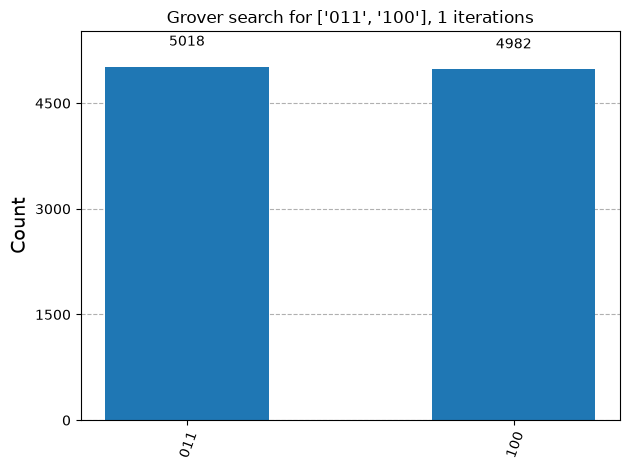

In [13]:
sampler = StatevectorSampler()
result = sampler.run([qc_grover], shots=10_000).result()
counts = result[0].data.meas.get_counts()

print("counts:", counts)
plot_histogram(counts, title=f"Grover search for {marked_states}, {optimal_iterations} iterations")

You should see the vast majority of the 10,000 shots land on `'011'` and `'100'` — the two marked states — even though we never told the algorithm *where* they were, only gave it oracle access to check a candidate. Compare that success probability to $M/N = 2/8 = 25\%$, which is what a single *classical* random guess would get right.

**Exercise:** search a 4-qubit space ($N=16$) for the single marked state `'1011'`. Compute the optimal number of iterations, build and run the circuit, and report the measured success probability (fraction of the 10,000 shots that landed on `'1011'`). It should be very close to 1.

In [14]:
marked_single = ["1011"]
oracle_single = grover_oracle(marked_single)
grover_op_single = grover_operator(oracle_single)
n_single = grover_op_single.num_qubits

iters_single = math.floor(math.pi / (4 * math.asin(math.sqrt(1 / 2 ** n_single))))

qc_single = QuantumCircuit(n_single)
qc_single.h(range(n_single))
qc_single.compose(grover_op_single.power(iters_single), inplace=True)
qc_single.measure_all()

counts_single = sampler.run([qc_single], shots=10_000).result()[0].data.meas.get_counts()
success = counts_single.get("1011", 0) / 10_000
print(f"N=16, iterations={iters_single}, measured success probability={success:.3f}")

N=16, iterations=3, measured success probability=0.961


---

## 5. How many iterations? Visualising Grover's oscillation

The optimal-iteration formula in section 4.3 comes from geometry: each application of $Q$ rotates the state by a fixed angle $\theta = 2\arcsin\sqrt{M/N}$ towards the marked subspace, so the success probability as a function of iteration count $r$ is exactly $\sin^2\!\big((2r+1)\theta/2\big)$ — it doesn't just increase and plateau, it **oscillates**. Let's see that directly with `Statevector`, without any sampling noise, by building circuits with $r = 0, 1, 2, \dots$ iterations and reading off the exact probability of landing on a marked state each time:

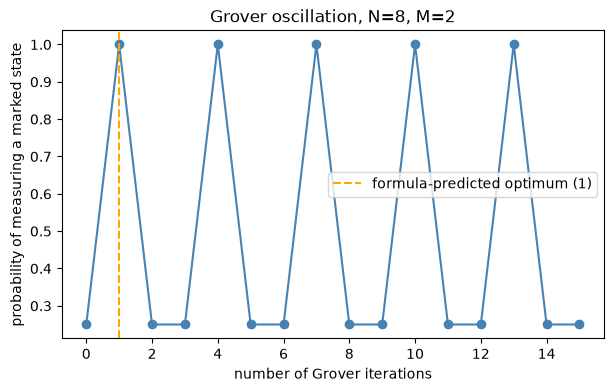

In [15]:
def marked_probability(oracle, marked_states, iterations, num_qubits):
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))
    if iterations > 0:
        grover_op = grover_operator(oracle)
        qc.compose(grover_op.power(iterations), inplace=True)
    probs = Statevector(qc).probabilities_dict()
    return sum(probs.get(state, 0.0) for state in marked_states)


max_iterations = 15
iteration_counts = list(range(max_iterations + 1))
success_probs = [marked_probability(oracle, marked_states, r, num_qubits) for r in iteration_counts]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iteration_counts, success_probs, marker="o", color="steelblue")
ax.axvline(optimal_iterations, color="orange", linestyle="--", label=f"formula-predicted optimum ({optimal_iterations})")
ax.set_xlabel("number of Grover iterations")
ax.set_ylabel("probability of measuring a marked state")
ax.set_title(f"Grover oscillation, N={N}, M={M}")
ax.legend()
plt.show()

The exact-probability curve should peak right at (or immediately next to — the formula rounds down, and the true optimum can fall between integers) the vertical line, then fall back down as you keep iterating past it: proof that "more iterations" isn't always better, unlike almost every classical algorithm you're used to reasoning about. This is exactly the same oscillating-then-overshooting-then-oscillating-again shape you'd get from amplitude amplification in general (Grover's algorithm is the special case of a broader technique called **amplitude amplification**, which shows up again in more advanced quantum algorithms beyond this school).

**Exercise:** repeat the plot for a single marked state out of $N=32$ ($n=5$ qubits). How does the optimal iteration count compare to the $N=8$, $M=2$ case above — does it go up or down, and does that match your intuition from the $\sqrt{N/M}$ scaling?

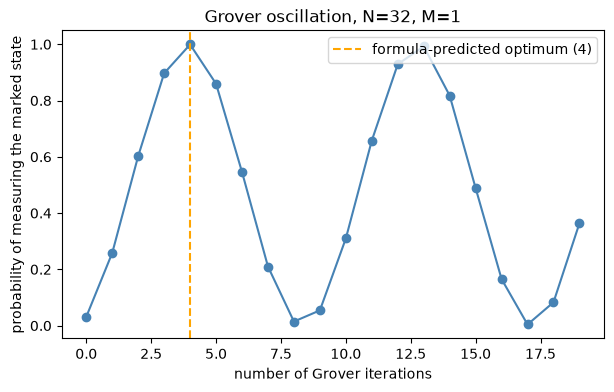

N=8,  M=2, optimal iterations = 1
N=32, M=1, optimal iterations = 4


In [16]:
marked_5q = ["10110"]
oracle_5q = grover_oracle(marked_5q)
n_5q = len(marked_5q[0])

iteration_counts_5q = list(range(20))
success_probs_5q = [marked_probability(oracle_5q, marked_5q, r, n_5q) for r in iteration_counts_5q]
optimal_5q = math.floor(math.pi / (4 * math.asin(math.sqrt(1 / 2 ** n_5q))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iteration_counts_5q, success_probs_5q, marker="o", color="steelblue")
ax.axvline(optimal_5q, color="orange", linestyle="--", label=f"formula-predicted optimum ({optimal_5q})")
ax.set_xlabel("number of Grover iterations")
ax.set_ylabel("probability of measuring the marked state")
ax.set_title(f"Grover oscillation, N=32, M=1")
ax.legend()
plt.show()

print(f"N=8,  M=2, optimal iterations = {optimal_iterations}")
print(f"N=32, M=1, optimal iterations = {optimal_5q}")

$N$ quadrupled (from 8 to 32) while $M$ dropped from 2 to 1 — so $N/M$ went up by a factor of 16, and since the iteration count scales like $\sqrt{N/M}$, we'd expect roughly a 4x increase, which is what the printed comparison should show (up to the usual floor-rounding).

---

## 6. Wrap-up

**What we covered:**

- An **oracle** is a black-box unitary; a **bit oracle** ($|x\rangle|y\rangle \mapsto |x\rangle|y\oplus f(x)\rangle$) and a **phase oracle** ($|x\rangle \mapsto (-1)^{f(x)}|x\rangle$) are interchangeable via **phase kickback**: run the bit oracle with its answer qubit prepared in $|-\rangle$.
- **Deutsch–Jozsa** distinguishes constant from balanced functions in exactly one quantum query, by using the oracle's phase kickback plus a layer of Hadamards before and after to turn a global property of $f$ (constant vs. balanced) into a deterministic measurement outcome.
- **Grover's algorithm** finds a marked item among $N$ in $O(\sqrt{N})$ oracle queries by repeatedly applying the **Grover operator** $Q$ — oracle reflection composed with a diffusion reflection — which rotates the state towards the marked subspace by a fixed angle each time.
- The number of Grover iterations matters: there's a closed-form optimum, $\lfloor \frac{\pi}{4\arcsin\sqrt{M/N}} \rfloor$, and running past it makes your success probability *worse*, not better — it's an oscillation, not a monotone climb.
- Both algorithms are instances of a broader pattern (superposition → oracle-induced relative phases → interference to make the phases observable) that recurs across quantum computing, right up to Shor's algorithm.

**Common pitfalls to watch for:**

- Building a **bit oracle** where Grover expects a **phase oracle** (or vice versa) — check which your circuit/library function expects before wiring it in.
- Forgetting phase kickback needs the ancilla in $|-\rangle$ specifically — $|0\rangle$ or $|1\rangle$ on the ancilla gives you no phase effect at all, and $|+\rangle$ gives you the wrong one.
- Assuming "more Grover iterations = better" — always compute (or scan, as in section 5) the optimal count rather than guessing generously.
- Mixing up Qiskit's little-endian bitstring convention when writing marked-state strings for `grover_oracle` — the `[::-1]` reversal inside the function above is there specifically to handle this; drop it and your oracle will mark the *bit-reversed* state instead of the one you intended.
- Applying `Sampler` primitives to circuits without `measure_all()` (or vice versa, `Estimator` to circuits *with* measurements) — same gotcha as Session 3.

**Cheat sheet**

| Concept | What it does | Qiskit |
|---|---|---|
| Bit oracle | $\lvert x\rangle\lvert y\rangle \mapsto \lvert x\rangle\lvert y\oplus f(x)\rangle$ | hand-built `QuantumCircuit` (CNOTs / Toffolis into an ancilla) |
| Phase kickback | turns a bit oracle into a phase oracle | prepare the ancilla in `H` then `X` (i.e. $\lvert-\rangle$) before applying the bit oracle |
| Phase oracle | $\lvert x\rangle \mapsto (-1)^{f(x)}\lvert x\rangle$ | `MCMTGate(ZGate(), ...)` sandwiched with `X` gates on the "0" bits |
| Deutsch–Jozsa | 1-query constant-vs-balanced test | `H` on all qubits, oracle, `H` on input qubits, measure |
| Grover operator | reflect-oracle then reflect-uniform | `qiskit.circuit.library.grover_operator(oracle)` |
| Optimal iterations | $\lfloor\pi / (4\arcsin\sqrt{M/N})\rfloor$ | `math.floor(math.pi / (4 * math.asin(math.sqrt(M / N))))` |
| Run & measure | shots → counts | `StatevectorSampler().run([qc], shots=n)` → `.data.meas.get_counts()` |
| Exact probability, no shots | inspect the statevector directly | `Statevector(qc).probabilities_dict()` |

That's the toolkit for building and reasoning about a genuine end-to-end quantum algorithm on a simulator — oracle construction, the interference mechanism that makes the algorithm work, and the practical Qiskit calls to build, run, and validate it.